In [1]:
import pandas as pd

In [2]:
courses=pd.read_csv('courses.csv')#id,name,course_name
students=pd.read_csv('students.csv')#id,name,partner
nov=pd.read_csv('reg-month1.csv')#id,course_id
dec=pd.read_csv('reg-month2.csv')#id,course_id

#ipl dataset
matches=pd.read_csv('matches.csv')
delivery=pd.read_csv('deliveries1.csv')

In [3]:
regs=pd.concat([nov,dec],ignore_index=True)
regs

,student_id,course_id
0,23,1
1,15,5
2,18,6
3,23,4
4,16,9
5,18,1
6,1,1
7,7,8
8,22,3
9,15,1


In [4]:
#MultiIndexing in Dataframe
multi=pd.concat([nov,dec],keys=['Nov','Dec'])

In [5]:
multi.loc[('Nov',0)]

student_id    23
course_id      1
Name: (Nov, 0), dtype: int64

In [6]:
pd.concat([nov,dec],axis=1)

,student_id,course_id,student_id,course_id
0,23.0,1.0,3,5
1,15.0,5.0,16,7
2,18.0,6.0,12,10
3,23.0,4.0,12,1
4,16.0,9.0,14,9
5,18.0,1.0,7,7
6,1.0,1.0,7,2
7,7.0,8.0,16,3
8,22.0,3.0,17,10
9,15.0,1.0,11,8


In [7]:
##pd.merge()
students.merge(regs,on='student_id')

,student_id,name,partner,course_id
0,1,Kailash Harjo,23,1
1,1,Kailash Harjo,23,6
2,1,Kailash Harjo,23,10
3,1,Kailash Harjo,23,9
4,2,Esha Butala,1,5
5,3,Parveen Bhalla,3,3
6,3,Parveen Bhalla,3,5
7,7,Tarun Thaker,9,8
8,7,Tarun Thaker,9,10
9,7,Tarun Thaker,9,7


In [8]:
##left join
courses.merge(regs,how="left",on='course_id')

,course_id,course_name,price,student_id
0,1,python,2499,23.0
1,1,python,2499,18.0
2,1,python,2499,1.0
3,1,python,2499,15.0
4,1,python,2499,21.0
5,1,python,2499,25.0
6,1,python,2499,12.0
7,1,python,2499,14.0
8,1,python,2499,38.0
9,2,sql,3499,19.0


In [9]:
#NO students enrolled in numpy and C++(Only retain all info of left table)

In [10]:
## right join
temp_df=pd.DataFrame({
    'student_id':[26,27,28],
    'name':['Nitish','Ankita','Swayam'],
    'partner':[26,28,17]
})
students=pd.concat([students,temp_df],ignore_index=True)

In [11]:
students.merge(regs,how='right',on='student_id')

,student_id,name,partner,course_id
0,23,Chhavi Lachman,18.0,1
1,15,Preet Sha,16.0,5
2,18,Fardeen Mahabir,13.0,6
3,23,Chhavi Lachman,18.0,4
4,16,Elias Dodiya,25.0,9
5,18,Fardeen Mahabir,13.0,1
6,1,Kailash Harjo,23.0,1
7,7,Tarun Thaker,9.0,8
8,22,Yash Sethi,21.0,3
9,15,Preet Sha,16.0,1


In [12]:
#outer (fetches all the data)
students.merge(regs,how='outer',on='student_id').tail(10)

,student_id,name,partner,course_id
53,23,Chhavi Lachman,18.0,5.0
54,24,Radhika Suri,17.0,4.0
55,25,Shashank D’Alia,2.0,1.0
56,25,Shashank D’Alia,2.0,10.0
57,26,Nitish,26.0,NaN
58,27,Ankita,28.0,NaN
59,28,Swayam,17.0,NaN
60,38,NaN,NaN,1.0
61,42,NaN,NaN,9.0
62,50,NaN,NaN,8.0


In [13]:
## 1. total revenue generated
total=regs.merge(courses,how='inner',on='course_id')

In [14]:
total['price'].sum()

154247

In [15]:
## find month by month revenue
regs

,student_id,course_id
0,23,1
1,15,5
2,18,6
3,23,4
4,16,9
5,18,1
6,1,1
7,7,8
8,22,3
9,15,1


In [16]:
temp=pd.concat([nov,dec],keys=['Nov','Dec']).reset_index()

In [17]:
join1=temp.merge(courses,how='inner',on='course_id')

In [18]:
join1.groupby('level_0')['price'].sum()

level_0
Dec    65072
Nov    89175
Name: price, dtype: int64

In [19]:
##3 Print the regs table
regs.merge(students,on='student_id').merge(courses,on='course_id')[['name','course_name','partner','price']]

,name,course_name,partner,price
0,Chhavi Lachman,python,18,2499
1,Preet Sha,tableau,16,2499
2,Fardeen Mahabir,power bi,13,1899
3,Chhavi Lachman,machine learning,18,9999
4,Elias Dodiya,plotly,25,699
5,Fardeen Mahabir,python,13,2499
6,Kailash Harjo,python,23,2499
7,Tarun Thaker,pandas,9,1099
8,Yash Sethi,data analysis,21,4999
9,Preet Sha,python,16,2499


<Axes: xlabel='course_name'>

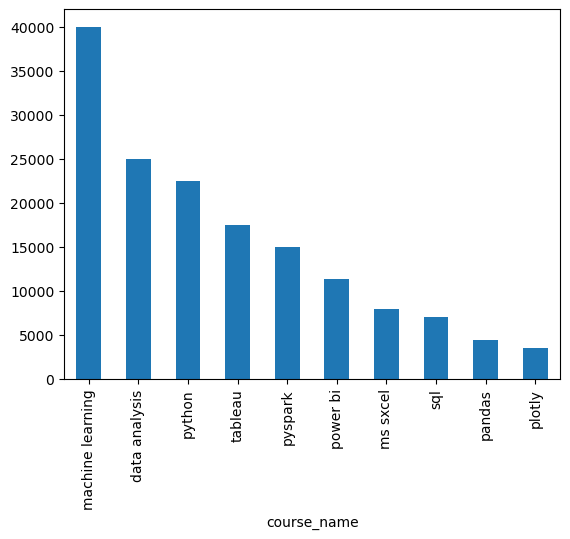

In [20]:
## 4 Plot Bar Chart for revenue/courses
regs.merge(courses,on='course_id').groupby(by='course_name')['price'].sum().sort_values(ascending=False).plot(kind='bar')

In [21]:
## 5.find students who enrolled in both the months
both=np.intersect1d(nov['student_id'],dec['student_id'])

<IPython.core.display.Javascript object>

In [22]:
students[students['student_id'].isin(both)]

,student_id,name,partner
0,1,Kailash Harjo,23
2,3,Parveen Bhalla,3
6,7,Tarun Thaker,9
10,11,David Mukhopadhyay,20
15,16,Elias Dodiya,25
16,17,Yasmin Palan,7
17,18,Fardeen Mahabir,13
21,22,Yash Sethi,21
22,23,Chhavi Lachman,18


In [23]:
## 6. Courses but not in regs

In [26]:
a=courses['course_id']
b=regs['course_id']
np.setdiff1d(a,b)

<IPython.core.display.Javascript object>

array([11, 12], dtype=int64)

In [30]:
# 7 Find students who did not enrolled in any course
student_list=np.setdiff1d(students['student_id'],regs['student_id'])
students[students['student_id'].isin(student_list)]

(10/28)*100

<IPython.core.display.Javascript object>

35.714285714285715

In [35]:
##8 Print student name>- partner name for all enrolled students
##self join
students.merge(students,how='inner',left_on='partner',right_on='student_id')[['name_x','name_y']]

,name_x,name_y
0,Kailash Harjo,Chhavi Lachman
1,Esha Butala,Kailash Harjo
2,Parveen Bhalla,Parveen Bhalla
3,Marlo Dugal,Pranab Natarajan
4,Kusum Bahri,Lakshmi Contractor
5,Lakshmi Contractor,Aayushman Sant
6,Tarun Thaker,Nitika Chatterjee
7,Radheshyam Dey,Kusum Bahri
8,Nitika Chatterjee,Marlo Dugal
9,Aayushman Sant,Radheshyam Dey


In [45]:
regs.merge(students,on='student_id').groupby(['student_id','name'])['name'].count().sort_values(ascending=False).head(3)

student_id  name          
23          Chhavi Lachman    6
7           Tarun Thaker      5
1           Kailash Harjo     4
Name: name, dtype: int64

In [46]:
regs.merge(students,on='student_id').merge(courses,on='course_id').groupby(['student_id','name'])['name'].count().sort_values(ascending=False).head(3)

student_id  name          
23          Chhavi Lachman    6
7           Tarun Thaker      5
1           Kailash Harjo     4
Name: name, dtype: int64

In [47]:
# 10. find top 3 students who spent most amount of money on courses
regs.merge(students,on='student_id').merge(courses,on='course_id').groupby(['student_id','name'])['price'].sum().sort_values(ascending=False).head(3)

student_id  name            
23          Chhavi Lachman      22594
14          Pranab Natarajan    15096
19          Qabeel Raman        13498
Name: price, dtype: int64

In [49]:
# pd.merge
pd.merge(students,regs,how='inner',on='student_id')

,student_id,name,partner,course_id
0,1,Kailash Harjo,23,1
1,1,Kailash Harjo,23,6
2,1,Kailash Harjo,23,10
3,1,Kailash Harjo,23,9
4,2,Esha Butala,1,5
5,3,Parveen Bhalla,3,3
6,3,Parveen Bhalla,3,5
7,7,Tarun Thaker,9,8
8,7,Tarun Thaker,9,10
9,7,Tarun Thaker,9,7


In [50]:
##ipl dataset

In [55]:
delivery=pd.read_csv('deliveries1.csv')

In [56]:
matches=pd.read_csv('matches.csv')

In [60]:
print(delivery.head(3))
print(matches.head(3))

   match_id  inning         batting_team                 bowling_team  over  \
0         1       1  Sunrisers Hyderabad  Royal Challengers Bangalore     1   
1         1       1  Sunrisers Hyderabad  Royal Challengers Bangalore     1   
2         1       1  Sunrisers Hyderabad  Royal Challengers Bangalore     1   

   ball    batsman non_striker    bowler  is_super_over  ...  bye_runs  \
0     1  DA Warner    S Dhawan  TS Mills              0  ...         0   
1     2  DA Warner    S Dhawan  TS Mills              0  ...         0   
2     3  DA Warner    S Dhawan  TS Mills              0  ...         0   

   legbye_runs  noball_runs  penalty_runs  batsman_runs  extra_runs  \
0            0            0             0             0           0   
1            0            0             0             0           0   
2            0            0             0             4           0   

   total_runs  player_dismissed dismissal_kind fielder  
0           0               NaN            N

In [62]:
temp_df=delivery.merge(matches,left_on='match_id',right_on='id')

In [65]:
six_df=temp_df[temp_df['batsman_runs']==6]

In [68]:
#sixes per stadium
six_stadium=six_df.groupby('venue')['venue'].count().sort_values(ascending=False)

In [74]:
num_matches=matches['venue'].value_counts().sort_values(ascending=False)

In [77]:
(six_stadium/num_matches).sort_values(ascending=False).head(10)

venue
Holkar Cricket Stadium                                 17.600000
M Chinnaswamy Stadium                                  13.227273
Sharjah Cricket Stadium                                12.666667
Himachal Pradesh Cricket Association Stadium           12.000000
Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium    11.727273
Wankhede Stadium                                       11.526316
De Beers Diamond Oval                                  11.333333
Maharashtra Cricket Association Stadium                11.266667
JSCA International Stadium Complex                     10.857143
Sardar Patel Stadium, Motera                           10.833333
dtype: float64

In [83]:
temp_df.groupby(['season','batsman'])['batsman_runs'].sum().reset_index().sort_values('season')

,season,batsman,batsman_runs
0,2008,A Chopra,42
99,2008,RR Sarwan,73
100,2008,RT Ponting,39
101,2008,RV Uthappa,320
102,2008,S Anirudha,1
...,...,...,...
1436,2017,I Sharma,8
1437,2017,IK Pathan,2
1438,2017,IR Jaggi,33
1458,2017,LMP Simmons,137


In [86]:
temp_df.groupby(['season','batsman'])['batsman_runs'].sum().reset_index().sort_values('batsman_runs',ascending=False).drop_duplicates(subset=['season'],keep='first').sort_values('season')

,season,batsman,batsman_runs
115,2008,SE Marsh,616
229,2009,ML Hayden,572
446,2010,SR Tendulkar,618
502,2011,CH Gayle,608
684,2012,CH Gayle,733
910,2013,MEK Hussey,733
1088,2014,RV Uthappa,660
1148,2015,DA Warner,562
1383,2016,V Kohli,973
1422,2017,DA Warner,641
